In [11]:
import numpy as np
import os
from matplotlib import pyplot as plt
from scipy.optimize import curve_fit
import matplotlib.gridspec as gridspec
import pyFAI
from pyFAI.azimuthalIntegrator import AzimuthalIntegrator;
import h5py
from scipy.ndimage import gaussian_filter

In [2]:
import scipy.io as spio

def loadmat(filename):
    '''
    this function should be called instead of direct spio.loadmat
    as it cures the problem of not properly recovering python dictionaries
    from mat files. It calls the function check keys to cure all entries
    which are still mat-objects
    '''
    data = spio.loadmat(filename, struct_as_record=False, squeeze_me=True)
    return _check_keys(data)

def _check_keys(dict):
    '''
    checks if entries in dictionary are mat-objects. If yes
    todict is called to change them to nested dictionaries
    '''
    for key in dict:
        if isinstance(dict[key], spio.matlab.mio5_params.mat_struct):
            dict[key] = _todict(dict[key])
    return dict        

def _todict(matobj):
    '''
    A recursive function which constructs from matobjects nested dictionaries
    '''
    dict = {}
    for strg in matobj._fieldnames:
        elem = matobj.__dict__[strg]
        if isinstance(elem, spio.matlab.mio5_params.mat_struct):
            dict[strg] = _todict(elem)
        else:
            dict[strg] = elem
    return dict


In [3]:
def stretched_exponential(x,a,b,c,d):
    return np.abs(a)*np.exp(-(x/np.abs(b))**c)+d

def double_exponential(x,a,b,c,d,e):
    return np.abs(a)*np.exp(-(x/(np.abs(b)))**c)+np.abs(c)*np.exp(-(x/(np.abs(d))))+e 

def linear(x,a,b):
    return a*x+b

def fit(function,x,y,p0=None,sigma=None, bounds=None,method={'trf'}):#bounds=((0.,0.,0.),(10., 10000.,5)),method={'trf'}):
    '''
    fits a function and return the fit resulting parameters and curve
    '''
    popt,pcov = curve_fit(function,x,y,p0=p0)#,sigma=sigma,bounds=bounds)
    curve = function(x,*popt)
    perr = np.sqrt(np.diag(pcov))
    return popt,x,curve,perr

### Sample name and paths

In [4]:
sample = 'NPL14B'
run = 169
path_to_data = '/asap3/petra3/gpfs/p10/2026/data/11023455/processed/RESULTS/'

### Load data

In [5]:
def load_g2(sample, run):
    file_name = path_to_data + f"%s_%05d_result.mat"%(sample,run)
    print(file_name)
    results_file = loadmat(file_name)
    Data = results_file['ccdimginfo']
    g2 = np.array(Data['result']['g2avg'])
    q = Data['dqspan']
    t=Data['result']['delay']
    return t, g2, q

In [6]:
t, g2, q = load_g2(sample, run)

/asap3/petra3/gpfs/p10/2026/data/11023455/processed/RESULTS/NPL14B_00169_result.mat


## Fit and plot data

[ 7.97007348e-01 -9.89816973e-05]


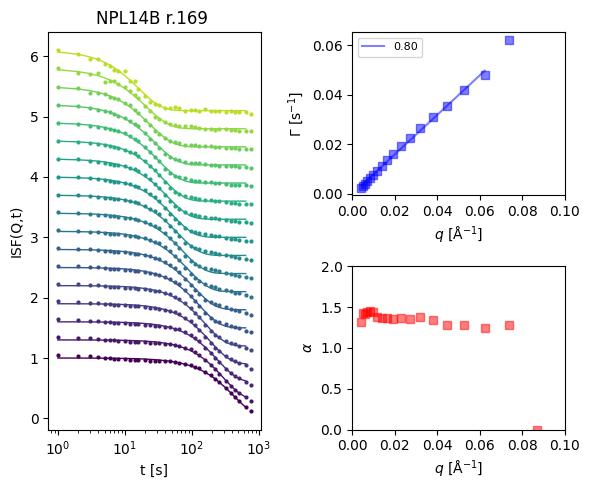

In [10]:
colors=[plt.cm.viridis(float(i)/(len(q))) for i in range(len(q))]
fig = plt.figure(figsize=(6, 5))
gs = gridspec.GridSpec(2, 2)

# XPCS
tau, kww = np.zeros(len(q)), np.zeros(len(q))
#dtau, dkww = np.zeros((n_spots, n)), np.zeros((n_spots, n))

it = -1
scale = 0.3
ax0 = fig.add_subplot(gs[:,0])
for iq in range(len(q)-1):
    x,y = t, g2[iq]
    popt,x_c,curve,perr = fit(stretched_exponential,x[:it],y[:it], p0= [0.1,300,1.,1.],bounds=([0,0.1,0,0.9],[.1,1000,2,1.1]))
    contrast, offset = abs(popt[0]), abs(popt[3])
    tau[iq],kww[iq] = abs(popt[1]), popt[2]
    ax0.errorbar(x,(y-offset)/contrast+iq*scale,color=colors[iq],ms=2,marker='o',ls='')
    ax0.plot(x_c,(curve-offset)/contrast+iq*scale,color=colors[iq],lw=1)         
ax0.set(xlabel='t [s]', ylabel=r'ISF(Q,t)', xscale='log')
ax0.set(title=f"%s r.%i "%(sample,run))


# tau plot
ax1 = fig.add_subplot(gs[0, 1])
ax1.plot(q,1./tau,marker='s', c='blue', ls='',alpha=0.5)
popt,x_c,curve,perr = fit(linear,q[:-2],1./tau[:-2])
print(popt)
ax1.plot(x_c,curve, c='blue', ls='-',alpha=0.5, label='%.2f'%popt[0])  

ax1.set_xlabel('$q$ [Å$^{-1}$]')
ax1.set_ylabel(r"$\Gamma$ [s$^{-1}$]")
ax1.set_xlim(0,0.1)
ax1.legend(loc='upper left', prop={'size': 8})

# kww plot
ax2 = fig.add_subplot(gs[1, 1])
ax2.errorbar(q,kww,marker='s', c='red', ls='',alpha=0.5)
ax2.set_xlabel('$q$ [Å$^{-1}$]')
ax2.set_ylabel(r"$\alpha$")
ax2.set_ylim(0,2)
ax2.set_xlim(0,0.1)
plt.tight_layout()
#plt.savefig(f"%s_q.png"%(sample), dpi=600)
plt.show()